# Assignment 2: Bond Sensitivity and CAPM Beta

This notebook preserves the completed solution logic and reorganizes it for
exam revision. Each question contains an English problem summary, an
independently runnable solution, Chinese line-level hints, and result guidance.

## Questions

1. Bond valuation and duration
2. Technology-stock CAPM beta estimation

## Recommended Answer Structure

1. State the financial or statistical objective.
2. Identify inputs, assumptions, and units.
3. Write the main formula or algorithm before coding.
4. Complete the code in execution order.
5. Report and interpret the result.
6. Add a short validation or reasonableness check.

## Assignment Review Checklist

- Each question can run independently.
- Imports are included in the question's own code cell.
- Random simulations use a fixed seed.
- The final answer includes interpretation, not only printed output.
- Any chart is discussed in the result Markdown.


## Question 1: Bond Valuation and Duration

Calculate price and Macaulay duration at two YTM levels, preserving the completed assignment logic.


### Structured Review

- **Cash flows:** Separate coupon payments, face value, dividends, and terminal value.
- **Rate convention:** Identify APR, effective period rate, effective annual rate, or continuous rate before substitution.
- **Discounting:** Match the payment frequency with the discount-rate frequency.
- **Risk interpretation:** Connect YTM and duration to bond-price sensitivity.

### Key Relationships

- Higher YTM generally implies a lower bond price.
- A coupon rate above YTM generally produces a premium bond.
- Earlier or larger cash flows generally reduce duration.
- One basis point equals `0.0001`.

### Exam Focus

- Calculate coupon per period and total number of periods.
- Add face value only to the final coupon cash flow.
- Distinguish Macaulay duration from modified duration.

### Common Mistakes

- Multiplying or dividing YTM by frequency in the wrong direction.
- Forgetting the negative cash-flow convention in financial-library functions.
- Using current dividend instead of next-period dividend in terminal value.


In [1]:
'''
本题计算附息债价格和 Macaulay 久期，并比较不同 YTM。
最后一期现金流需要加回面值，这是常见代码填空点。
'''
def bond_price(face_value, coupon_rate, ytm, years, frequency):
    coupon = face_value * coupon_rate / frequency
    periods = years * frequency
    return sum(
        (coupon + (face_value if period == periods else 0))
        / (1 + ytm / frequency) ** period
        for period in range(1, periods + 1)
    )

def calculate_duration(face_value, coupon_rate, ytm, years, frequency):
    periods = years * frequency
    coupon = face_value * coupon_rate / frequency
    price = bond_price(face_value, coupon_rate, ytm, years, frequency)
    duration = 0.0

    for period in range(1, periods + 1):
        time = period / frequency
        # 到期现金流 = 票息 + 面值
        cash_flow = coupon + (face_value if period == periods else 0)
        present_value = cash_flow / (1 + ytm / frequency) ** period
        # 现值占债券价格的比例是久期权重
        duration += (present_value / price) * time
    return price, duration

for ytm in (0.05, 0.08):
    price, duration = calculate_duration(1000, 0.07, ytm, 10, 2)
    print(f"YTM={ytm:.0%}: price={price:.2f}, duration={duration:.4f}")


YTM=5%: price=1155.89, duration=7.5648
YTM=8%: price=932.05, duration=7.2465


**Result interpretation.** Higher YTM lowers both price and duration in this example.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

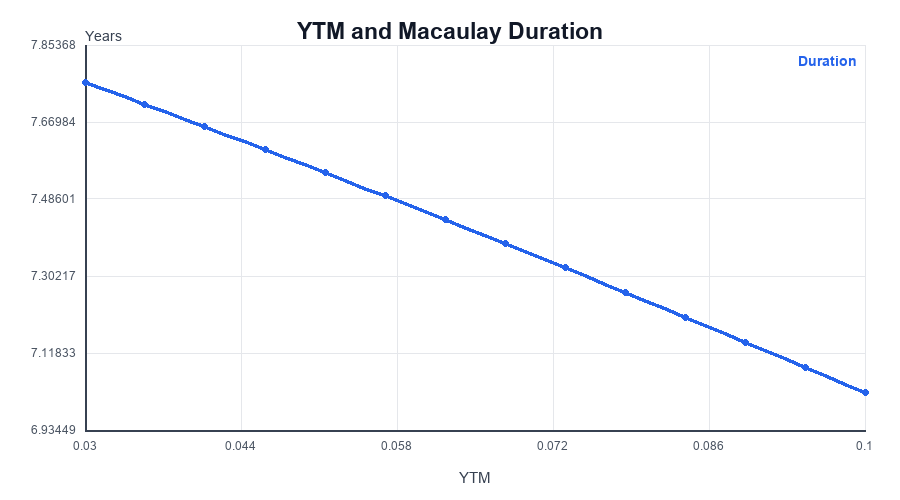


## Question 2: Technology-Stock CAPM Beta

Estimate AAPL beta against a simulated S&P 500 factor and test whether the slope is significant.


### Structured Review

- **Dependent variable:** Asset return or asset excess return belongs on the left-hand side.
- **Independent variable:** Market return or market excess return explains the asset.
- **Intercept:** A constant column is required when alpha is estimated.
- **Alignment:** Join datasets by matching dates before running the regression.

### Interpretation

- `alpha` measures the intercept or abnormal return.
- `beta` measures sensitivity to the market factor.
- `R-squared` measures the proportion of sample variation explained by the model.
- A p-value evaluates statistical significance, not economic size.

### Exam Focus

- Preserve the order `x = market`, `y = stock`.
- Add a constant before OLS.
- Read the beta from the market coefficient, not the intercept.

### Common Mistakes

- Reversing stock and market inputs in `linregress`.
- Merging unmatched dates without checking missing values.
- Treating a high beta as proof of a high realized return.


In [2]:
'''
本题估计 CAPM 回归 AAPLret = alpha + beta*MktRet + error。
使用矩阵 OLS，并从残差计算 beta 的 p 值。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(17)
n = 252
market_returns = rng.normal(0.0004, 0.011, n)
aapl_returns = 0.0002 + 1.25 * market_returns + rng.normal(0, 0.012, n)

# 常数列用于估计 alpha
X = np.column_stack([np.ones(n), market_returns])
coefficients = np.linalg.lstsq(X, aapl_returns, rcond=None)[0]
residuals = aapl_returns - X @ coefficients

df = n - X.shape[1]
residual_variance = np.sum(residuals**2) / df
covariance = residual_variance * np.linalg.inv(X.T @ X)
beta_standard_error = np.sqrt(covariance[1, 1])

# beta 的 t 检验原假设为 beta=0
t_value = coefficients[1] / beta_standard_error
p_value = 2 * (1 - stats.t.cdf(abs(t_value), df))

fitted = X @ coefficients
r_squared = 1 - np.sum(residuals**2) / np.sum((aapl_returns - aapl_returns.mean())**2)

print("Alpha =", round(float(coefficients[0]), 6))
print("Beta =", round(float(coefficients[1]), 4))
print("R-squared =", round(float(r_squared), 4))
print("Beta p-value =", round(float(p_value), 8))


Alpha = -0.000151
Beta = 1.26
R-squared = 0.5664
Beta p-value = 0.0


**Result interpretation.** The estimated beta should be near the simulated value of 1.25 and statistically significant.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

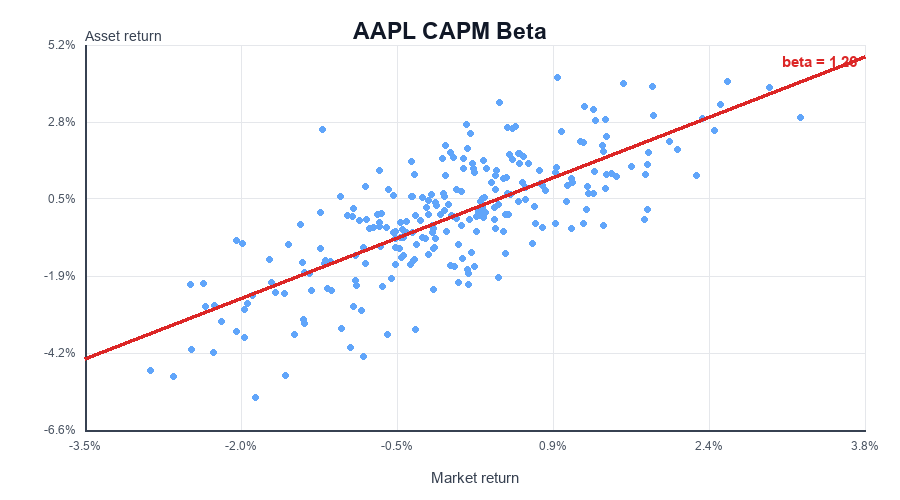
